In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
import scienceplots
plt.style.use(['science'])

In [2]:
def alpha_m(V):
    return 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10))

def beta_m(V):
    return 4.0 * np.exp(-0.0556 * (V + 65))

def alpha_h(V):
    return 0.07 * np.exp(-0.05 * (V + 65))

def beta_h(V):
    return 1 / (1 + np.exp(-(V + 35) / 10))

def alpha_n(V):
    return 0.01 * (V + 55) / (1 - np.exp(-(V + 55) / 10))

def beta_n(V):
    return 0.125 * np.exp(-0.0125 * (V + 65))

def hh_model(y, I):
    V, m, h, n = y
    
    C_m  = 1.0
    g_Na = 120.0
    g_K  = 36.0
    g_L  = 0.3
    E_Na = 50.0
    E_K  = -77.0
    E_L  = -54.4
    
    dVdt = (I - g_Na * m**3 * h * (V - E_Na) - g_K * n**4 * (V - E_K) - g_L * (V - E_L)) / C_m
    dmdt = alpha_m(V) * (1 - m) - beta_m(V) * m
    dhdt = alpha_h(V) * (1 - h) - beta_h(V) * h
    dndt = alpha_n(V) * (1 - n) - beta_n(V) * n
    
    return np.array([dVdt, dmdt, dhdt, dndt])

dt      = 0.05
t_final = 100
n_steps = int(t_final / dt)

t   = np.arange(0, t_final, dt)
V   = np.zeros(n_steps)
m   = np.zeros(n_steps)
h   = np.zeros(n_steps)
n   = np.zeros(n_steps)
dV  = np.zeros(n_steps)
dm  = np.zeros(n_steps)
dh  = np.zeros(n_steps)
dn  = np.zeros(n_steps)

# -63.74660111687549,
# 0.0579677361572967,
# 0.45181238339387086,
# 0.3986286597964018

V[0]    = -60.47271020589096
m[0]    = 0.0840395577340696
h[0]    = 0.4589340518422895
n[0]    = 0.3890302094251769
I       = 10.0  

for i in range(1, n_steps):
    dydt = hh_model([V[i-1], m[i-1], h[i-1], n[i-1]], I)
    V[i] = V[i-1] + dt * dydt[0]
    m[i] = m[i-1] + dt * dydt[1]
    h[i] = h[i-1] + dt * dydt[2]
    n[i] = n[i-1] + dt * dydt[3]
    dV[i], dm[i], dh[i], dn[i] = dydt
    


In [3]:
data = np.transpose([t, V, m, h, n, dV, dm, dh, dn])
np.savetxt('hh-data.txt', data)

In [4]:
V[-1], m[-1], h[-1], n[-1]

(np.float64(-64.97031344416547),
 np.float64(0.05025318463310694),
 np.float64(0.4425709180282641),
 np.float64(0.4072075293229723))

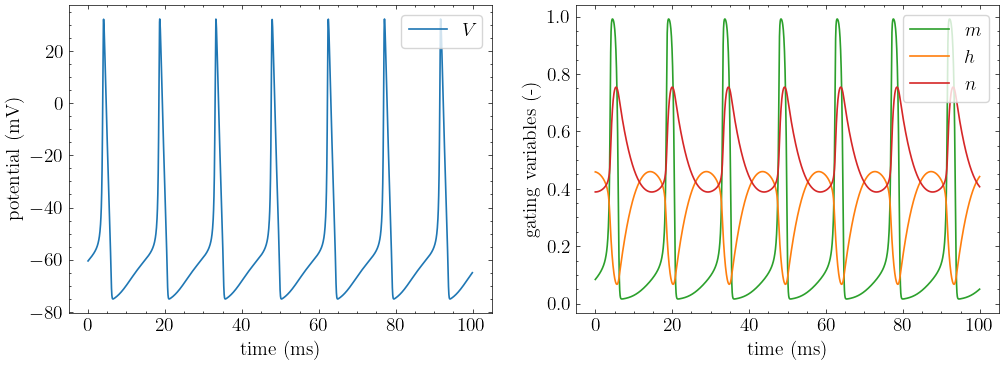

In [5]:
plt.figure(figsize=(12, 4))
plt.rc('font', size=14)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_iter = iter(colors)

c0 = next(color_iter)
c1 = next(color_iter)
c2 = next(color_iter)
c3 = next(color_iter)
# c4 = next(color_iter)

plt.subplot(1, 2, 1)
plt.plot(t, V, '-', color='tab:blue', label="$V$", linewidth=1.2, alpha=1.0)
plt.legend(loc='upper right', frameon=True, framealpha=0.8, fancybox=True)
plt.ylabel('potential (mV)')
plt.xlabel('time (ms)')

plt.subplot(1, 2, 2)
plt.plot(t, m, '-', color='tab:green', label="$m$", linewidth=1.2, alpha=1.0)
plt.plot(t, h, '-', color='tab:orange', label="$h$", linewidth=1.2, alpha=1.0)
plt.plot(t, n, '-', color='tab:red', label="$n$", linewidth=1.2, alpha=1.0)
plt.ylabel('gating variables (-)')
plt.xlabel('time (ms)')
plt.legend(loc='upper right', frameon=True, framealpha=0.8, fancybox=True)
plt.savefig('hh_model.pdf', dpi=300)
plt.show()

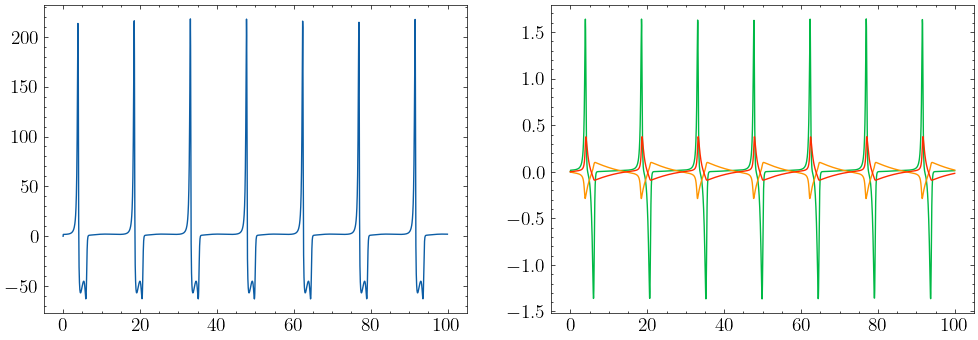

In [6]:
plt.figure(figsize=(12, 4))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_iter = iter(colors)

plt.subplot(1, 2, 1)
plt.plot(t, dV, color=next(color_iter))
# plt.ylabel('dV/dt (mV/ms)')

plt.subplot(1, 2, 2)
plt.plot(t, dm, color=next(color_iter))
plt.plot(t, dh, color=next(color_iter))
plt.plot(t, dn, color=next(color_iter))

plt.show()